# SHAP Analysis — Vectyfi Radar XGBoost

Explain predictions of the XGBoost model trained to predict EU public tender award (`awarded` = 1 vs 0).

**Sections:**
1. Setup & data rebuild
2. SHAP explainer
3. Global importance (beeswarm + bar)
4. Dependence plots (top features)
5. Single-prediction waterfall

## 1. Setup & Imports

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

shap.initjs()
print("✅ All imports loaded")

✅ All imports loaded


## 2. Rebuild Data & Model

Replicates the exact preprocessing from the main notebook so SHAP runs against the same model.

In [15]:
FILE_PATH = '/Users/basile/code/Tescoa00/raw_data/export_CFC_2018_2023.csv'

df_raw = pd.read_csv(FILE_PATH, nrows=500_000, low_memory=False)
print(f"✅ Loaded: {df_raw.shape[0]:,} rows * {df_raw.shape[1]} columns")

✅ Loaded: 500,000 rows * 64 columns


In [40]:
if 'WIN_NAME' in df_raw.columns and 'AWARD_VALUE_EURO' in df_raw.columns:
    df_raw['y'] = ((df_raw['WIN_NAME'].notna()) | (df_raw['AWARD_VALUE_EURO'] > 0)).astype(int)
elif 'FUTURE_CAN_ID' in df_raw.columns:
    df_raw['y'] = df_raw['FUTURE_CAN_ID'].notna().astype(int)
else:
    raise ValueError('No valid target columns found in dataset!')

# --- Target Distribution ---
n_pos = df_raw['y'].sum()
n_neg = len(df_raw) - n_pos
imbalance_ratio = n_neg / n_pos

FEATURES_TO_KEEP = [
    # Structurelles
    "LOTS_NUMBER",
    "days_to_deadline",
    "VALUE_EURO",
    "YEAR",
    "DURATION",
    # CPV / secteur
    "CPV",
    "cpv4",
    "ADDITIONAL_CPVS",
    "MAIN_ACTIVITY",
    # Géographie
    "ISO_COUNTRY_CODE",
    "TAL_LOCATION_NUTS",
    "ADMIN_LANGUAGES_TENDER",
    # Critères
    "CRIT_CODE",
    "CRIT_CRITERIA",
    "CRIT_WEIGHTS",
    "CRIT_PRICE_WEIGHT",
    # Framework
    "B_FRA_AGREEMENT",
    "B_FRA_SINGLE_OPERATOR",
    "FRA_NUMBER_OPERATORS",
    "FRA_NUMBER_MAX_OPERATORS",
    "FRA_ESTIMATED",
    # Contrat
    "CONTRACT_START",
    "CONTRACT_COMPLETION",
    "CAE_TYPE",
    "TOP_TYPE",
    "TYPE_OF_CONTRACT",
    "ID_TYPE",
    # Flags binaires
    "B_GPA",
    "B_EU_FUNDS",
    "B_OPTIONS",
    "B_VARIANTS",
    "B_ACCELERATED",
    "B_ON_BEHALF",
    "B_RECURRENT_PROCUREMENT",
    "B_ELECTRONIC_AUCTION",
    "B_DYN_PURCH_SYST",
    "B_AWARDED_BY_CENTRAL_BODY",
    "B_INVOLVES_JOINT_PROCUREMENT",
    # Autres
    "CORRECTIONS",
    "XSD_VERSION",
    "CANCELLED",
    "month_dispatch",
    "has_value",
    "has_corrections",
    "EU_INST_CODE",
    "DT_DISPATCH",
    "DT_APPLICATIONS"
]

FEATURES = [f for f in FEATURES_TO_KEEP if f in df_raw.columns]
df = df_raw[[c for c in FEATURES if c in df_raw.columns] + ['y']].copy()
print(f"✅ Loaded: {df.shape[0]:,} rows * {df.shape[1]} columns")

✅ Loaded: 500,000 rows * 43 columns


In [41]:
print(df.columns.tolist())

['LOTS_NUMBER', 'VALUE_EURO', 'YEAR', 'DURATION', 'CPV', 'ADDITIONAL_CPVS', 'MAIN_ACTIVITY', 'ISO_COUNTRY_CODE', 'TAL_LOCATION_NUTS', 'ADMIN_LANGUAGES_TENDER', 'CRIT_CODE', 'CRIT_CRITERIA', 'CRIT_WEIGHTS', 'CRIT_PRICE_WEIGHT', 'B_FRA_AGREEMENT', 'B_FRA_SINGLE_OPERATOR', 'FRA_NUMBER_OPERATORS', 'FRA_NUMBER_MAX_OPERATORS', 'FRA_ESTIMATED', 'CONTRACT_START', 'CONTRACT_COMPLETION', 'CAE_TYPE', 'TOP_TYPE', 'TYPE_OF_CONTRACT', 'ID_TYPE', 'B_GPA', 'B_EU_FUNDS', 'B_OPTIONS', 'B_VARIANTS', 'B_ACCELERATED', 'B_ON_BEHALF', 'B_RECURRENT_PROCUREMENT', 'B_ELECTRONIC_AUCTION', 'B_DYN_PURCH_SYST', 'B_AWARDED_BY_CENTRAL_BODY', 'B_INVOLVES_JOINT_PROCUREMENT', 'CORRECTIONS', 'XSD_VERSION', 'CANCELLED', 'EU_INST_CODE', 'DT_DISPATCH', 'DT_APPLICATIONS', 'y']


### Features engineering

In [42]:
# Date features (only if columns survived the leakage filter)
for col in ['DT_DISPATCH', 'DT_APPLICATIONS']:
    if col in df.columns and not pd.api.types.is_datetime64_any_dtype(df[col]):
        df[col] = pd.to_datetime(df[col], dayfirst=True, format='mixed', errors='coerce')

if 'cpv4' not in df.columns:
    df['cpv4'] = df['CPV'].astype(str).str[:4]
if 'month_dispatch' not in df.columns:
    df['month_dispatch'] = df['DT_DISPATCH'].dt.month if 'DT_DISPATCH' in df.columns else 0
if 'is_end_of_year' not in df.columns:
    df['is_end_of_year'] = df['month_dispatch'].isin([11, 12]).astype(int)
if 'days_to_deadline' not in df.columns:
    df['days_to_deadline'] = (
        (df['DT_APPLICATIONS'] - df['DT_DISPATCH']).dt.days.clip(0, 365).fillna(30)
        if 'DT_DISPATCH' in df.columns and 'DT_APPLICATIONS' in df.columns else 30
    )
if 'has_value' not in df.columns:
    df['has_value'] = (df['VALUE_EURO'] > 0).astype(int)
if 'has_corrections' not in df.columns:
    df['has_corrections'] = (df['CORRECTIONS'] > 0).astype(int)

df = df.drop(columns=['DT_DISPATCH', 'DT_APPLICATIONS'], errors='ignore')

# Encode categoricals
cat_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

X = df.drop(columns=['y']).fillna(0)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (400000, 46), Test: (100000, 46)


In [43]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)
print("✅ Model trained")

[0]	validation_0-logloss:0.35114
[50]	validation_0-logloss:0.22271
[100]	validation_0-logloss:0.20290
[150]	validation_0-logloss:0.18915
[200]	validation_0-logloss:0.17909
[250]	validation_0-logloss:0.17071
[299]	validation_0-logloss:0.16338
✅ Model trained


In [44]:
from sklearn.inspection import permutation_importance
pi = permutation_importance(xgb, X_test, y_test, n_repeats=10, random_state=42)

pi_df = pd.DataFrame({
    "feature":    X_test.columns,
    "importance": pi.importances_mean,
    "std":        pi.importances_std
}).sort_values("importance", ascending=False)

# Afficher le tableau
print(pi_df.to_string(index=False))

# Features qui font du bruit (importance négative ou nulle)
print("\n⚠️ Features inutiles ou nuisibles:")
print(pi_df[pi_df["importance"] <= 0])

                     feature  importance      std
                 LOTS_NUMBER    0.026241 0.000292
      ADMIN_LANGUAGES_TENDER    0.015497 0.000238
            days_to_deadline    0.010028 0.000253
           TAL_LOCATION_NUTS    0.010003 0.000228
                        YEAR    0.006949 0.000222
                  VALUE_EURO    0.004789 0.000232
                        cpv4    0.003403 0.000214
                         CPV    0.003339 0.000193
            ISO_COUNTRY_CODE    0.003333 0.000306
             ADDITIONAL_CPVS    0.003068 0.000176
                    DURATION    0.003003 0.000202
               MAIN_ACTIVITY    0.002869 0.000184
                   CRIT_CODE    0.002692 0.000158
                    CAE_TYPE    0.002492 0.000093
                 CORRECTIONS    0.001719 0.000112
       B_FRA_SINGLE_OPERATOR    0.001610 0.000133
                CRIT_WEIGHTS    0.001507 0.000179
                 XSD_VERSION    0.001360 0.000180
           CRIT_PRICE_WEIGHT    0.001296 0.000079


In [45]:
y_prob = xgb.predict_proba(X_test)[:, 1]
roc = roc_auc_score(y_test, y_prob)
pr = average_precision_score(y_test, y_prob)

print(f"ROC-AUC: {roc:.4f} | PR-AUC: {pr:.4f}")

ROC-AUC: 0.9588 | PR-AUC: 0.9941


## 3. SHAP Explainer

We use `TreeExplainer` (exact, fast for XGBoost). We sample 5 000 test rows to keep plots readable.

In [46]:
SAMPLE_SIZE = 5_000
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_test), size=SAMPLE_SIZE, replace=False)
X_sample = X_test.iloc[sample_idx]

explainer = shap.TreeExplainer(xgb)
shap_values = explainer(X_sample)   # returns Explanation object

print(f"SHAP values shape: {shap_values.values.shape}")
print(f"Base value (log-odds): {shap_values.base_values[0]:.4f}")

SHAP values shape: (5000, 46)
Base value (log-odds): 2.0598


## 4. Global Feature Importance

### 4a. Beeswarm plot — shows impact distribution per feature

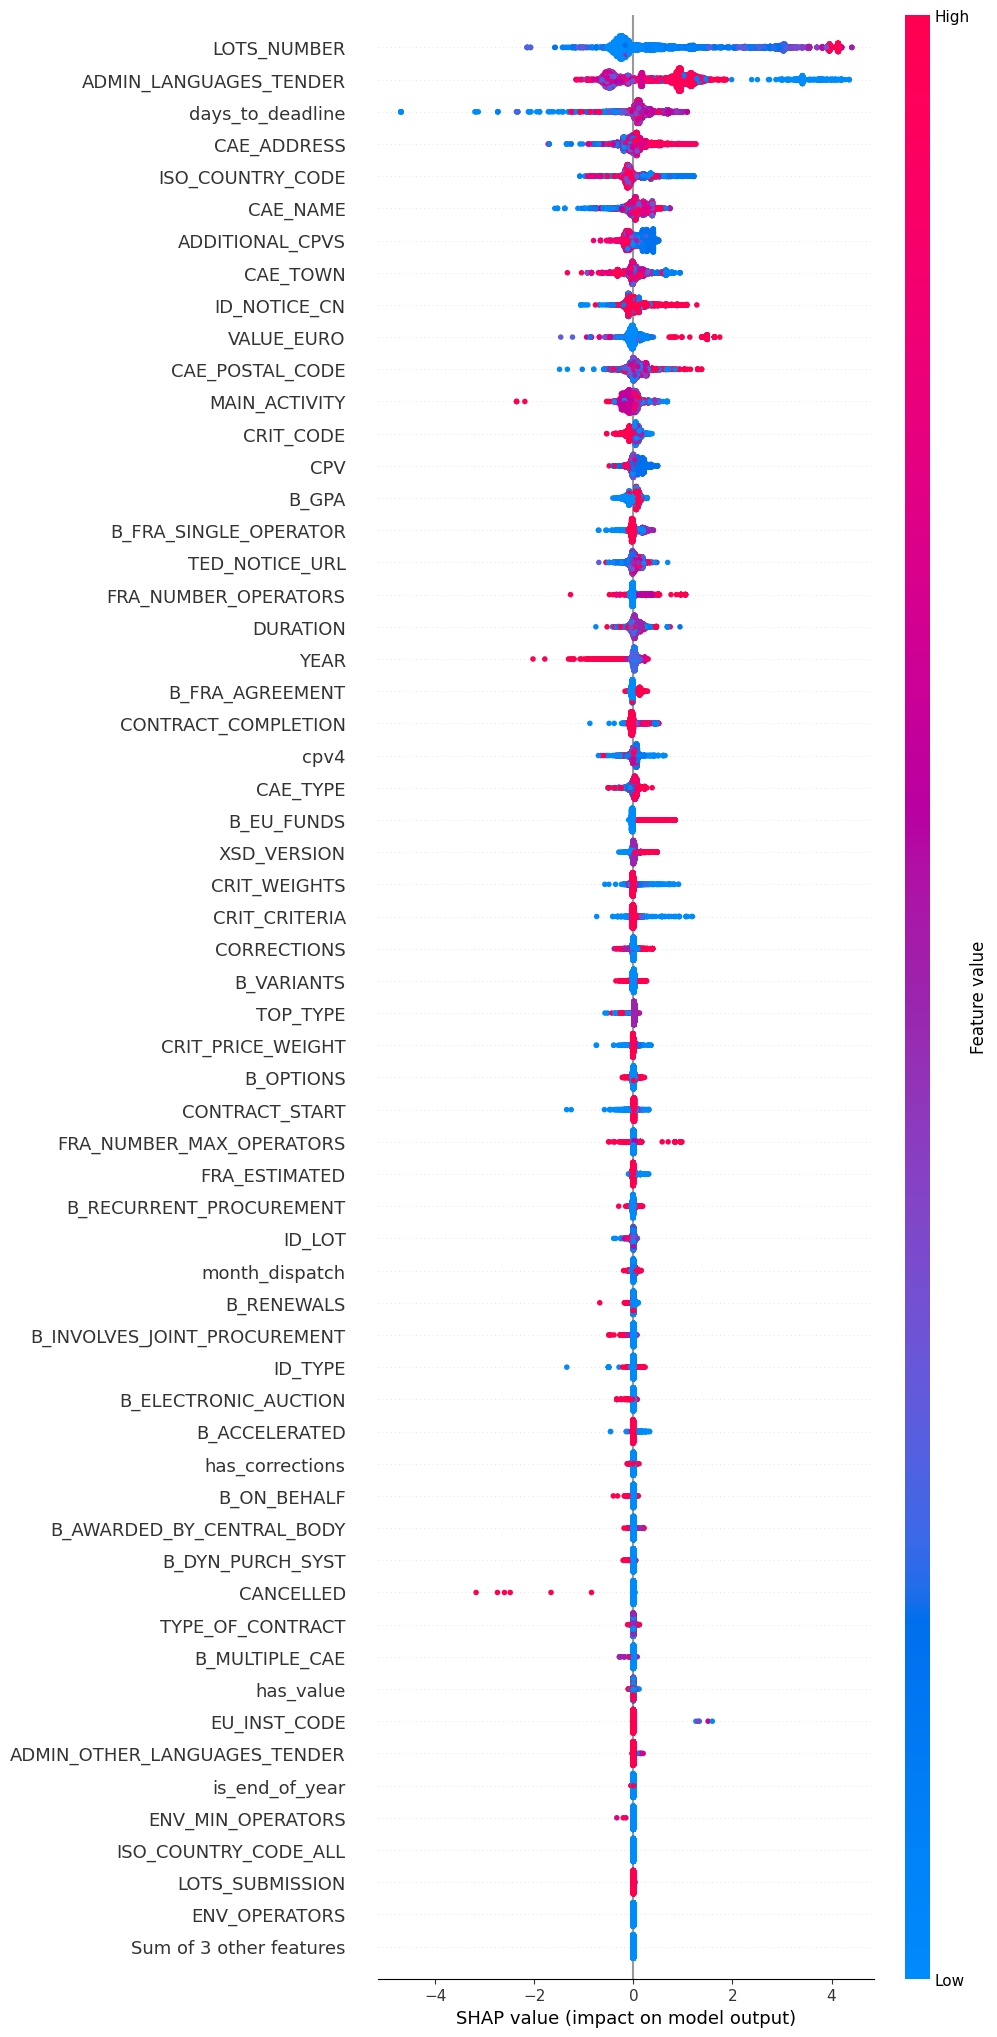

In [22]:
shap.plots.beeswarm(shap_values, max_display=60, show=True)

### 4b. Bar plot — mean |SHAP| per feature (simpler ranking)

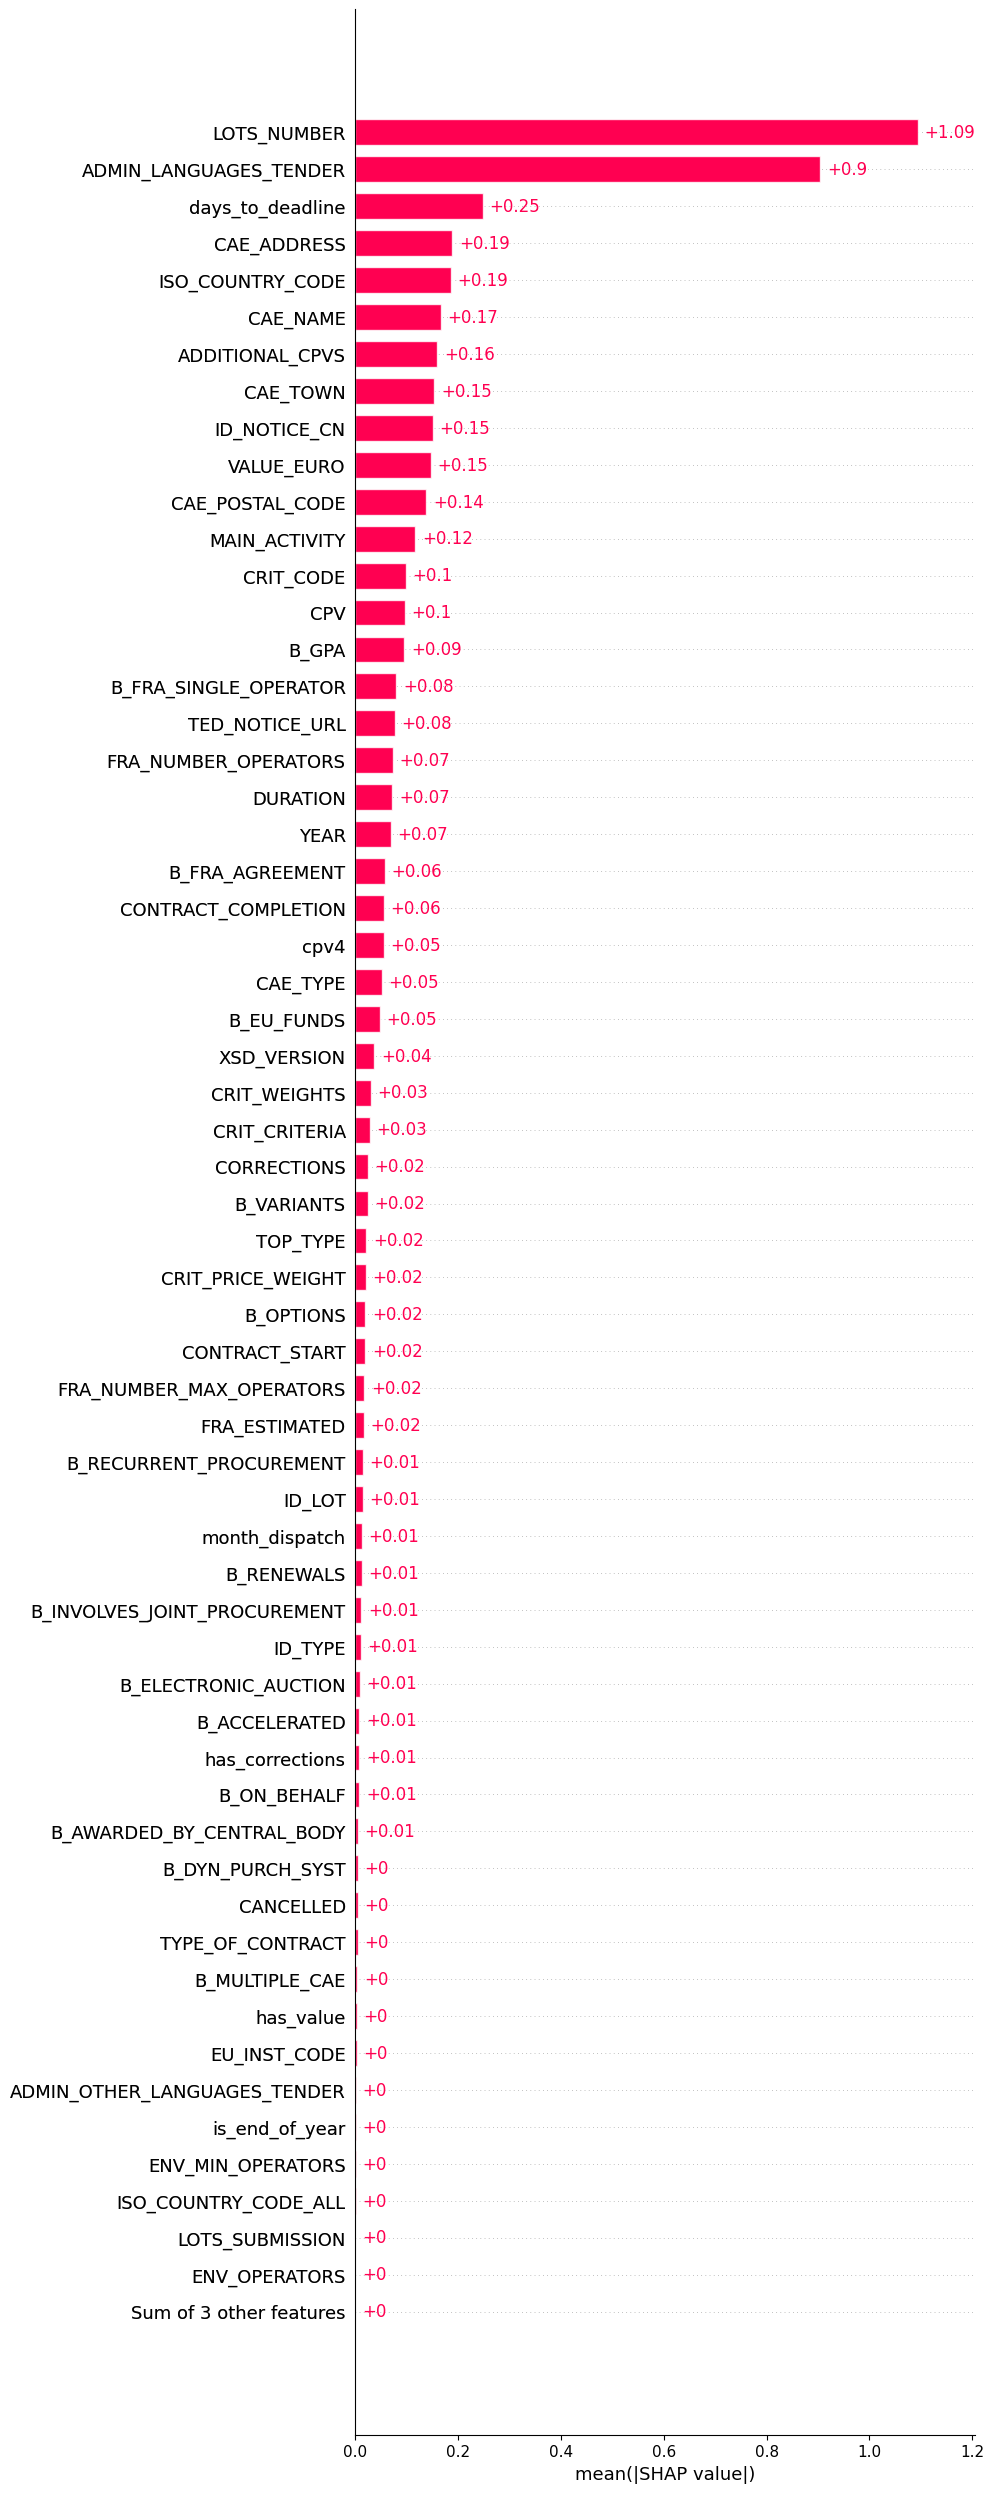

In [23]:
shap.plots.bar(shap_values, max_display=60, show=True)

## 5. Dependence Plots

How each top feature's value relates to its SHAP impact. The color encodes the most interacting feature (chosen automatically).

Top 5 features: ['LOTS_NUMBER', 'ADMIN_LANGUAGES_TENDER', 'days_to_deadline', 'CAE_ADDRESS', 'ISO_COUNTRY_CODE']


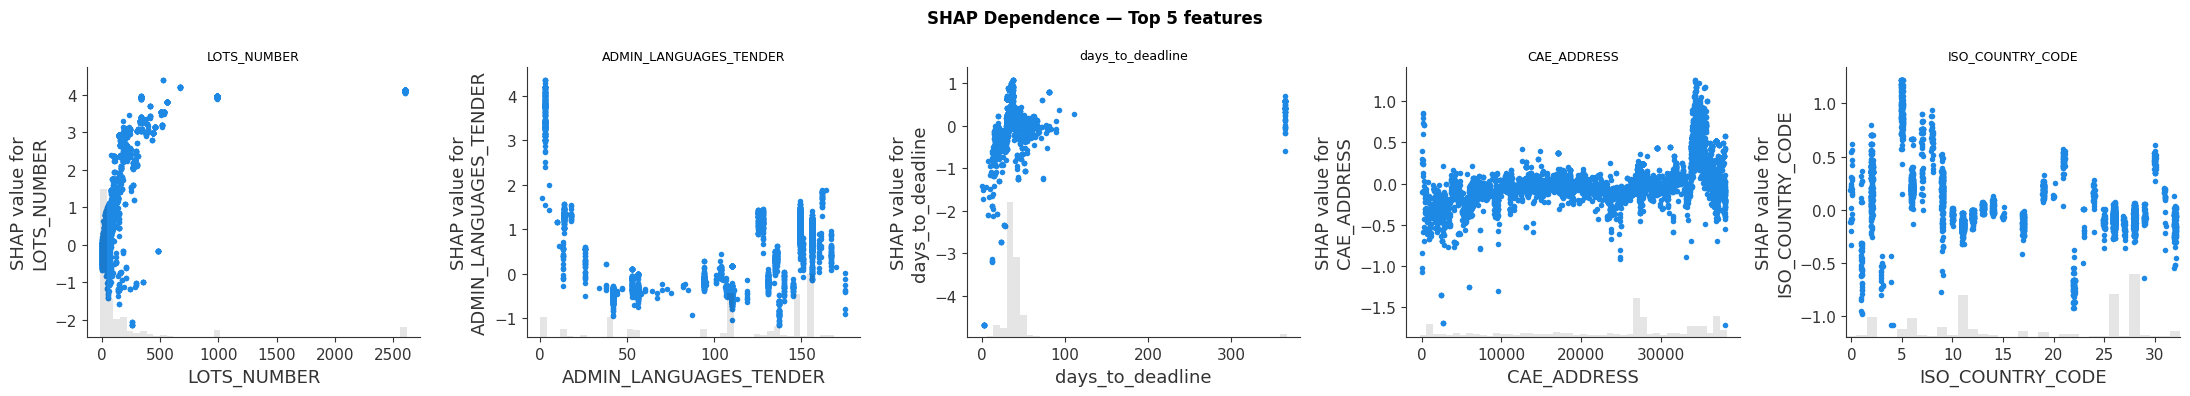

In [24]:
# Top-5 features by mean |SHAP|
mean_abs = np.abs(shap_values.values).mean(axis=0)
top5_features = X_sample.columns[np.argsort(mean_abs)[::-1][:5]].tolist()
print("Top 5 features:", top5_features)

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, feat in zip(axes, top5_features):
    shap.plots.scatter(shap_values[:, feat], ax=ax, show=False)
    ax.set_title(feat, fontsize=9)
plt.suptitle("SHAP Dependence — Top 5 features", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Waterfall — Single Prediction Explanation

Inspect one individual prediction (edit `ROW` to pick another).

Row 0 | True label: 1 | Predicted P(awarded): 1.000


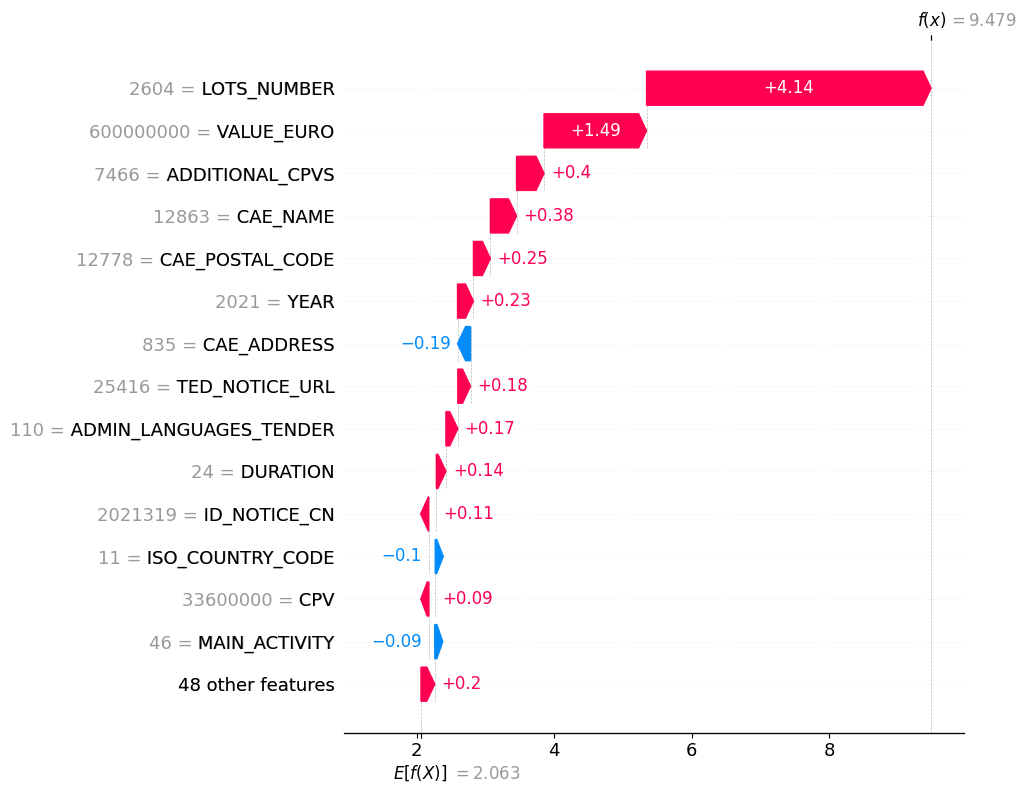

In [25]:
ROW = 0   # change to any index in [0, SAMPLE_SIZE)

pred_prob = xgb.predict_proba(X_sample.iloc[[ROW]])[0, 1]
true_label = y_test.iloc[sample_idx[ROW]]
print(f"Row {ROW} | True label: {true_label} | Predicted P(awarded): {pred_prob:.3f}")

shap.plots.waterfall(shap_values[ROW], max_display=15, show=True)

## 7. SHAP Values Table

Raw SHAP values for the sample — useful for downstream analysis or export.

In [26]:
shap_df = pd.DataFrame(shap_values.values, columns=X_sample.columns)
shap_df.insert(0, 'awarded_true', y_test.iloc[sample_idx].values)
shap_df.insert(1, 'pred_prob', xgb.predict_proba(X_sample)[:, 1])

print(shap_df.shape)
shap_df.head()

(5000, 64)


,awarded_true,pred_prob,ID_NOTICE_CN,TED_NOTICE_URL,YEAR,ID_TYPE,XSD_VERSION,CANCELLED,CORRECTIONS,B_MULTIPLE_CAE,...,B_LANGUAGE_ANY_EC,ADMIN_LANGUAGES_TENDER,ADMIN_OTHER_LANGUAGES_TENDER,B_RECURRENT_PROCUREMENT,cpv4,month_dispatch,is_end_of_year,days_to_deadline,has_value,has_corrections
0,1,0.999924,0.112551,0.184861,0.231360,-0.002050,0.033994,0.001842,-0.016998,0.003741,...,0.0,0.172525,-0.000087,-0.005930,0.061965,0.043276,-0.001310,0.082520,-0.002390,0.010418
1,1,0.929080,-0.035529,0.042220,0.002329,-0.005808,-0.000314,0.002251,0.020057,0.000995,...,0.0,0.253791,-0.000430,-0.007283,-0.041791,0.008203,0.000091,0.115714,-0.001160,0.002069
2,1,0.950328,0.072841,0.081347,0.034984,-0.002102,0.011765,0.002130,0.009696,-0.003252,...,0.0,-0.142784,-0.000246,0.008287,-0.016643,-0.003097,0.000061,0.205082,-0.003945,0.002352
3,1,0.999982,-0.072450,0.029838,0.105261,-0.001589,0.037008,0.001392,0.010152,0.003645,...,0.0,3.381415,-0.000195,0.004830,0.084620,-0.010532,0.000084,0.386694,-0.000703,0.006532
4,1,0.741050,0.029871,-0.013966,0.003511,-0.013533,0.007581,0.002335,0.001600,0.001124,...,0.0,-0.534300,-0.000007,-0.026660,0.245757,0.035322,0.000091,-0.191915,0.005395,0.000226
